Data acquired from https://www.kaggle.com/datasets/jamiewelsh2/nba-per-game-player-statistics-2022-2023-season

In [1]:
import numpy as np
import pandas as pd

In [2]:
nba = pd.read_csv('nba_per_game_processed.csv')

In [3]:
nba.head()

,Index,Player Name,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,1,Precious Achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,...,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2,achiupr01
1,2,Steven Adams,C,29,MEM,42,42,27.0,3.7,6.3,...,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6,adamsst01
2,3,Bam Adebayo,C,25,MIA,75,75,34.6,8.0,14.9,...,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4,adebaba01
3,4,Ochai Agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,...,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9,agbajoc01
4,5,Santi Aldama,PF,22,MEM,77,20,21.8,3.2,6.8,...,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0,aldamsa01


In [4]:
len(nba)

539

In [5]:
nba.columns

Index(['Index', 'Player Name', 'Position', 'Age', 'Team', 'GP', 'GS', 'MP',
       'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'Player-additional'],
      dtype='object')

In [6]:
nba = nba.drop(columns=['Index', 'Player Name', 'DRB', 'FG', 'STL', 'BLK', '3P', '2P', 'FT', 'DRB', 'TRB', 'TOV', 'Team',
         'Player-additional', 'GS'])

In [7]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

In [8]:
nba.isnull().sum()

Position     0
Age          0
GP           0
MP           0
FGA          0
FG%          2
3PA          0
3P%         16
2PA          0
2P%          5
eFG%         2
FTA          0
FT%         24
ORB          0
AST          0
PF           0
PTS          0
dtype: int64

In [9]:
nba['Position'].value_counts()

SG       126
C        108
SF       103
PF       102
PG        91
SG-PG      2
SF-SG      2
PG-SG      2
SF-PF      1
PF-C       1
PF-SF      1
Name: Position, dtype: int64

In [10]:
nba.loc[nba['Position']=='SG-PG', 'Position']='SG'
nba.loc[nba['Position']=='SF-SG', 'Position']='SF'
nba.loc[nba['Position']=='PG-SG', 'Position']='PG'
nba.loc[nba['Position']=='SF-PF', 'Position']='SF'
nba.loc[nba['Position']=='PF-C', 'Position']='PF'
nba.loc[nba['Position']=='PF-SF', 'Position']='PF'

In [11]:
nba['Position'].value_counts()

SG    128
C     108
SF    106
PF    104
PG     93
Name: Position, dtype: int64

In [12]:
nba.loc[nba['PTS']==0]

,Position,Age,GP,MP,FGA,FG%,3PA,3P%,2PA,2P%,eFG%,FTA,FT%,ORB,AST,PF,PTS
66,SF,27,4,6.0,1.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,NaN,0.8,0.5,1.0,0.0
72,PF,29,2,3.0,1.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
150,PF,20,1,1.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0
232,PG,24,1,5.0,3.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,NaN,1.0,1.0,0.0,0.0
514,SG,23,1,5.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,1.0,0.0


<AxesSubplot:>

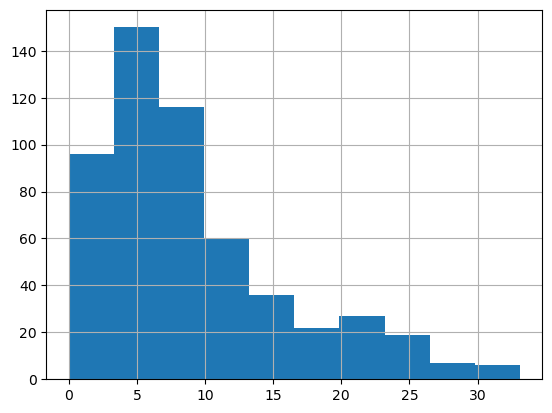

In [13]:
nba['PTS'].hist()

In [14]:
from sklearn.model_selection import train_test_split
nba_train, nba_test = train_test_split(nba, test_size = 0.33, random_state = 42)

In [15]:
nba = nba_train.copy()

<AxesSubplot:xlabel='eFG%', ylabel='PTS'>

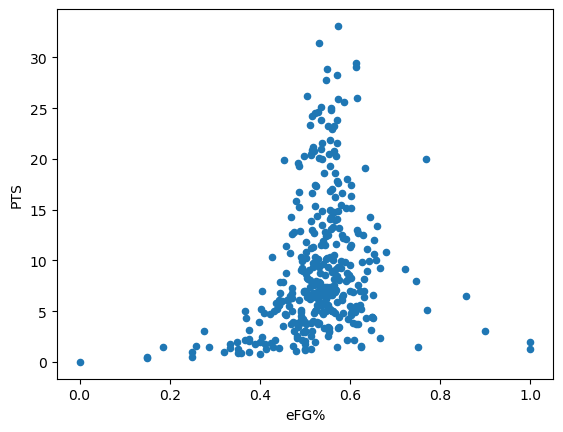

In [16]:
nba.plot(kind='scatter', x='eFG%', y='PTS')

In [17]:
corr_matrix = nba.corr()
corr_matrix['PTS'].sort_values(ascending=False)

PTS     1.000000
FGA     0.980864
2PA     0.925813
FTA     0.889202
MP      0.874249
AST     0.695174
3PA     0.687654
PF      0.616771
GP      0.530135
ORB     0.332981
eFG%    0.239718
FG%     0.232870
FT%     0.210664
3P%     0.188328
Age     0.165106
2P%     0.150192
Name: PTS, dtype: float64

array([[<AxesSubplot:xlabel='PTS', ylabel='PTS'>,
        <AxesSubplot:xlabel='2PA', ylabel='PTS'>,
        <AxesSubplot:xlabel='FGA', ylabel='PTS'>,
        <AxesSubplot:xlabel='FTA', ylabel='PTS'>,
        <AxesSubplot:xlabel='MP', ylabel='PTS'>],
       [<AxesSubplot:xlabel='PTS', ylabel='2PA'>,
        <AxesSubplot:xlabel='2PA', ylabel='2PA'>,
        <AxesSubplot:xlabel='FGA', ylabel='2PA'>,
        <AxesSubplot:xlabel='FTA', ylabel='2PA'>,
        <AxesSubplot:xlabel='MP', ylabel='2PA'>],
       [<AxesSubplot:xlabel='PTS', ylabel='FGA'>,
        <AxesSubplot:xlabel='2PA', ylabel='FGA'>,
        <AxesSubplot:xlabel='FGA', ylabel='FGA'>,
        <AxesSubplot:xlabel='FTA', ylabel='FGA'>,
        <AxesSubplot:xlabel='MP', ylabel='FGA'>],
       [<AxesSubplot:xlabel='PTS', ylabel='FTA'>,
        <AxesSubplot:xlabel='2PA', ylabel='FTA'>,
        <AxesSubplot:xlabel='FGA', ylabel='FTA'>,
        <AxesSubplot:xlabel='FTA', ylabel='FTA'>,
        <AxesSubplot:xlabel='MP', ylabel='FTA'>],


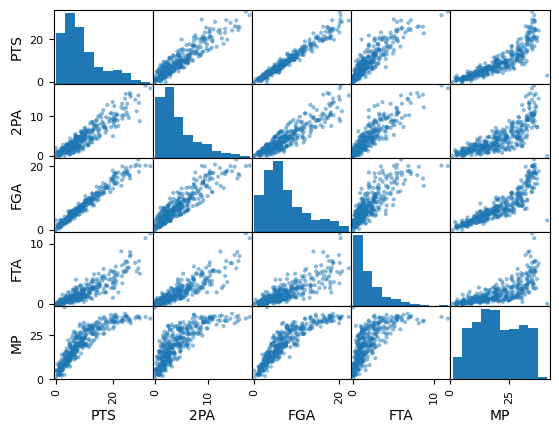

In [18]:
from pandas.plotting import scatter_matrix
attr = ['PTS', '2PA', 'FGA', 'FTA', 'MP']
scatter_matrix(nba[attr])

In [19]:
# dropping labels for training set
nba = nba_train.drop('PTS', axis = 1)
nba_labels = nba_train['PTS'].copy()

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
# replacing NaN values with 0 and scaling values
nbanum_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0)),
                         ('scaler', StandardScaler())])

In [22]:
nbanum = nba.drop('Position', axis = 1)
num_attr = list(nbanum)
cat_attr = ['Position']
ct = ColumnTransformer([('num', nbanum_pipeline, num_attr),
                       ('cat', OneHotEncoder(), cat_attr)])
nba_ready = ct.fit_transform(nba)

In [23]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(nba_ready, nba_labels)

LinearRegression()

In [24]:
from sklearn.metrics import mean_squared_error
nba_pred = lin_reg.predict(nba_ready)
lin_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
lin_rmse

0.6713000691457692

In [25]:
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(nba_labels, nba_pred)
lin_mae

0.449398856914148

In [26]:
first5 = nba.iloc[:5]
first5_labels = nba_labels.iloc[:5]
first5_t = ct.transform(first5)
print('Predictions:', lin_reg.predict(first5_t))

Predictions: [ 3.84682605 29.00041238  6.13305699 24.69510897 20.89142652]


In [27]:
print('Labels:', list(first5_labels))

Labels: [3.8, 28.9, 6.2, 24.5, 21.6]


In [28]:
from sklearn.model_selection import cross_val_score
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
scores = cross_val_score(lin_reg, nba_ready, nba_labels, scoring = 'neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-scores)
display_scores(rmse_scores)

Scores: [0.59897914 0.64242752 1.17529729 0.71460608 0.97069364 0.63635522
 0.60579667 0.72811354 0.68329188 0.45786261]
Mean: 0.7213423597485054
Standard deviation: 0.1951885525504744


In [29]:
from sklearn.svm import SVR
svr_lin = SVR(kernel='linear')
svr_lin.fit(nba_ready, nba_labels)
nba_pred = svr_lin.predict(nba_ready)
svr_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
svr_rmse

0.693233519244358

In [30]:
svr_scores = cross_val_score(svr_lin, nba_ready, nba_labels, scoring = 'neg_mean_squared_error', cv=10)
svr_rmse_scores = np.sqrt(-svr_scores)
display_scores(svr_rmse_scores)

Scores: [0.54480521 0.62818385 1.24060635 0.62516613 0.9504715  0.5914628
 0.6878918  0.75871602 0.64543779 0.45822239]
Mean: 0.7130963851836054
Standard deviation: 0.2156216796557144


In [31]:
from sklearn.ensemble import RandomForestRegressor
freg = RandomForestRegressor(random_state=42)
freg.fit(nba_ready, nba_labels)

RandomForestRegressor(random_state=42)

In [32]:
nba_pred = freg.predict(nba_ready)
freg_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
freg_rmse

0.34587377807534136

In [33]:
freg_scores = cross_val_score(freg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10)
freg_rmse_scores = np.sqrt(-freg_scores)
display_scores(freg_rmse_scores)

Scores: [0.83645046 1.22977891 0.72074051 0.66661221 1.17957509 1.20351873
 0.93066255 0.87129721 0.70071065 0.5731016 ]
Mean: 0.8912447924398208
Standard deviation: 0.2274332124384424


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'n_estimators':[80, 90, 100], 'max_features':[4, 8, 12, 15]},
             {'bootstrap':[False], 'n_estimators':[5, 10, 15], 'max_features':[2, 3, 4]}]
new_freg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(new_freg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(nba_ready, nba_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [4, 8, 12, 15],
                          'n_estimators': [80, 90, 100]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [5, 10, 15]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [35]:
grid_search.best_params_

{'max_features': 12, 'n_estimators': 90}

In [36]:
best_freg = grid_search.best_estimator_

In [37]:
fi = best_freg.feature_importances_
fi

array([1.20035200e-03, 2.26385525e-03, 1.03504192e-01, 5.83835160e-01,
       4.63865943e-03, 5.33679088e-03, 1.65460835e-03, 2.11013896e-01,
       3.85611544e-03, 4.84947589e-03, 6.66523064e-02, 2.20463910e-03,
       1.13903917e-03, 5.21753402e-03, 2.03876103e-03, 8.28689924e-05,
       1.54340595e-04, 1.09702155e-04, 1.42120215e-04, 1.05582850e-04])

In [38]:
cat_encoder = ct.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attr + cat_one_hot_attribs
sorted(zip(fi, attributes), reverse=True)

[(0.5838351598605744, 'FGA'),
 (0.21101389592605144, '2PA'),
 (0.1035041924250736, 'MP'),
 (0.06665230641795877, 'FTA'),
 (0.005336790882633441, '3PA'),
 (0.005217534015875648, 'AST'),
 (0.004849475893475692, 'eFG%'),
 (0.004638659429053633, 'FG%'),
 (0.003856115436081324, '2P%'),
 (0.0022638552502531996, 'GP'),
 (0.0022046391040733177, 'FT%'),
 (0.0020387610333092916, 'PF'),
 (0.0016546083463159092, '3P%'),
 (0.0012003519974666265, 'Age'),
 (0.0011390391748597314, 'ORB'),
 (0.00015434059519087243, 'PF'),
 (0.00014212021474690553, 'SF'),
 (0.00010970215497942827, 'PG'),
 (0.00010558284965664476, 'SG'),
 (8.28689923701545e-05, 'C')]

In [39]:
best_freg_scores = cross_val_score(best_freg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10)
bfreg_rmse_scores = np.sqrt(-best_freg_scores)
display_scores(bfreg_rmse_scores)

Scores: [0.83620516 1.15627014 0.86479404 0.71826325 1.23890269 1.14719684
 0.84530804 0.85301662 0.63518087 0.58890671]
Mean: 0.8884044340090632
Standard deviation: 0.21230531567275882


In [40]:
from sklearn.tree import DecisionTreeRegressor
dtreg = DecisionTreeRegressor(random_state=42)
dtreg.fit(nba_ready, nba_labels)

DecisionTreeRegressor(random_state=42)

In [41]:
nba_pred = dtreg.predict(nba_ready)
dt_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
dt_rmse

9.052369020945807e-17

In [42]:
dt_rmse_scores = np.sqrt(-cross_val_score(dtreg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10))
display_scores(dt_rmse_scores)

Scores: [1.35786    2.31312679 1.34008706 1.03494498 1.5541164  1.34886784
 1.42253686 1.23625779 1.13663734 1.18532696]
Mean: 1.392976202233878
Standard deviation: 0.33779696490580224


In [43]:
nba_ftest = nba_test.drop('PTS', axis=1)
nba_tlabels = nba_test['PTS'].copy()
nba_test_prep = ct.transform(nba_test)
final_predictions_freg = best_freg.predict(nba_test_prep)
final_rmse_freg = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_freg))
final_rmse_freg

0.79475594759002

In [44]:
final_predictions_lin = lin_reg.predict(nba_test_prep)
final_rmse_lin = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_lin))
final_rmse_lin

0.6879390356344091

In [45]:
final_predictions_svr = svr_lin.predict(nba_test_prep)
final_rmse_svr = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_svr))
final_rmse_svr

0.6882194167637161

In [46]:
final_predictions_tree = dtreg.predict(nba_test_prep)
final_rmse = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_tree))
final_rmse

1.0311169900602994